In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from sklearn.decomposition import PCA
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser

## Load *C. elegans* Neuronal Data (excluding behavioural neurons)

In [2]:
worm_num = 0
b_neurons = [
    'AVAR',
    'AVAL',
    'SMDVR',
    'SMDVL',
    'SMDDR',
    'SMDDL',
    'RIBR',
    'RIBL'
]
data_path = '../datasets/raw/c_elegans/NoStim_Data.mat'
data = Database(data_path=data_path, dataset_no=worm_num)
data.exclude_neurons(b_neurons)
x = data.neuron_traces.T
b = data.behaviour


## Visualise Neuronal and Behavioural data

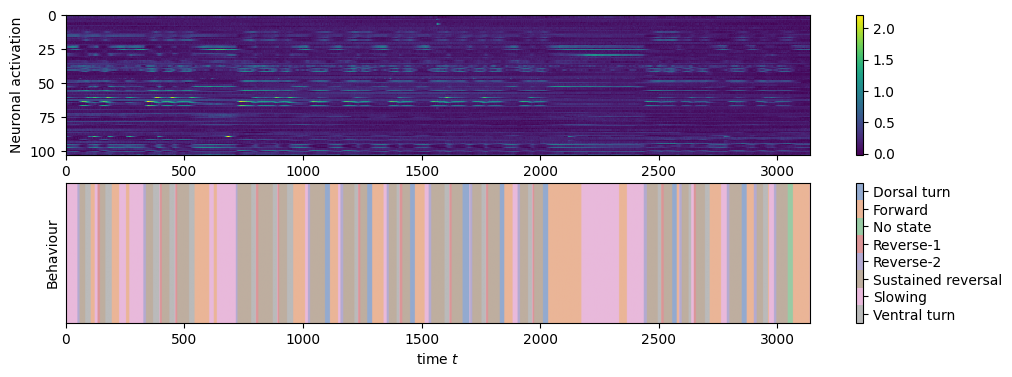

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [3]:
plotting_neuronal_behavioural(x, b, b_names=data.behaviour_names)

## Latent time series visualisation

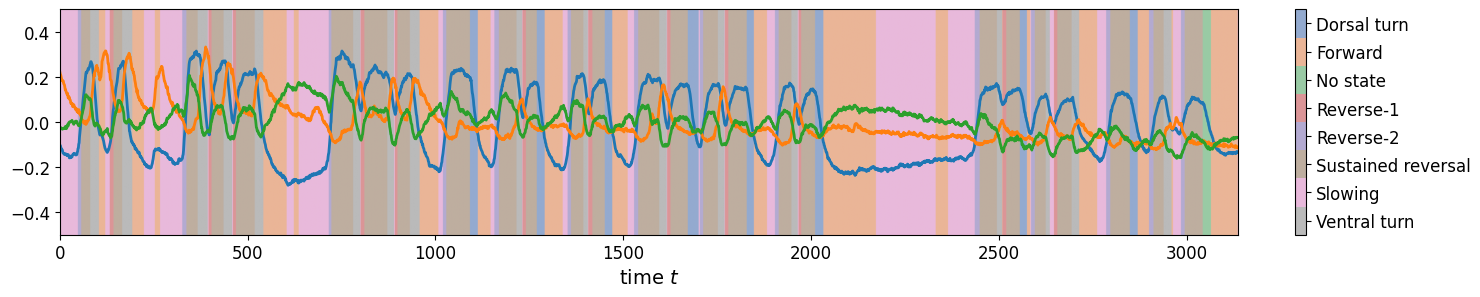

In [4]:
# To use the comparison plot we first need an embedding
pca = PCA(n_components=3)
y_pca = pca.fit_transform(x)
vis = LatentSpaceVisualiser(y_pca, b, b_names=data.behaviour_names, legend=True)
vis.plot_latent_timeseries()

## Phase space dynamics visualisation

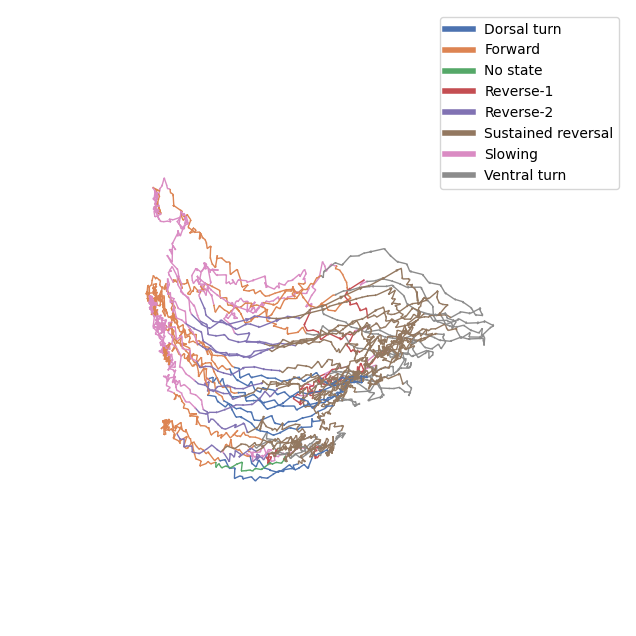

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [5]:
vis.plot_phase_space()

## Visualising BunDLe-Net manifold with the visualiser

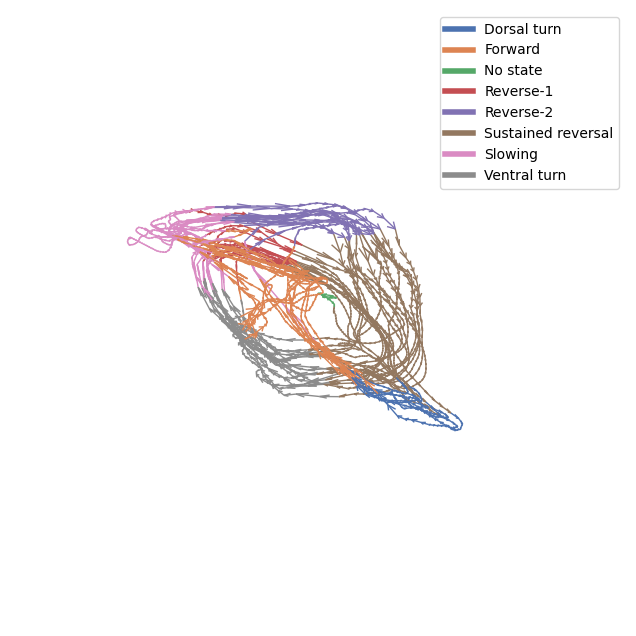

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [6]:
# Load Bundle-Net trajectory for visualisation
y = np.loadtxt('../datasets/generated/saved_embeddings/Y0__BunDLeNet_worm_0')
b = np.loadtxt('../datasets/generated/saved_embeddings/B__BunDLeNet_worm_0')
nData = -1
vis = LatentSpaceVisualiser(
    y[:nData], 
    b[:nData], 
    b_names=data.behaviour_names, 
    legend=True
)
vis.plot_phase_space()

It is straightforward to change the color scheme of the behaviour. The data points can also be made visible in the embedding.

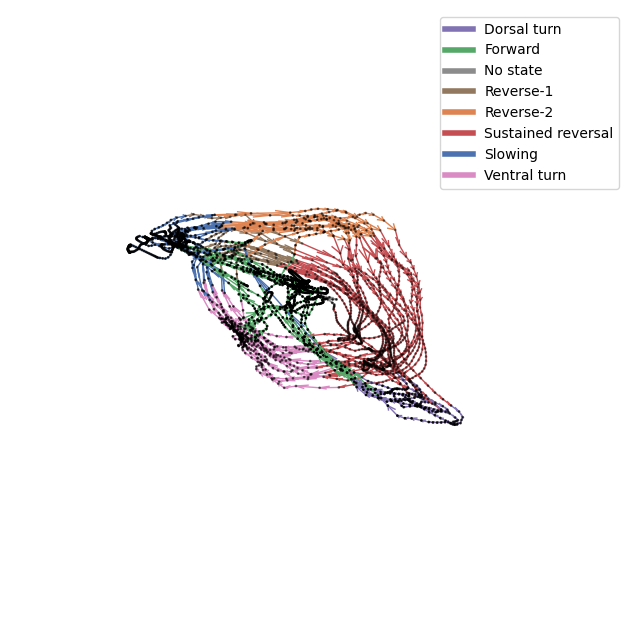

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [7]:
import seaborn as sns
deep_palette = sns.color_palette('deep', 8)
colors = [deep_palette[i] for i in [4,2,7,5,1,3,0,6]]
nData = -1
vis = LatentSpaceVisualiser(
    y[:nData], 
    b[:nData], 
    b_names=data.behaviour_names, 
    legend=True,
    colors=colors, 
    show_points=True
)
vis.plot_phase_space()

## Visualise state space dynamics in real time (GIF)
This function creates an animated movie that visualizes how the point moves through the state space over time.

Creating movie: 100%|██████████████████████████████████████████| 3121/3121 [2:20:19<00:00,  2.70s/it]


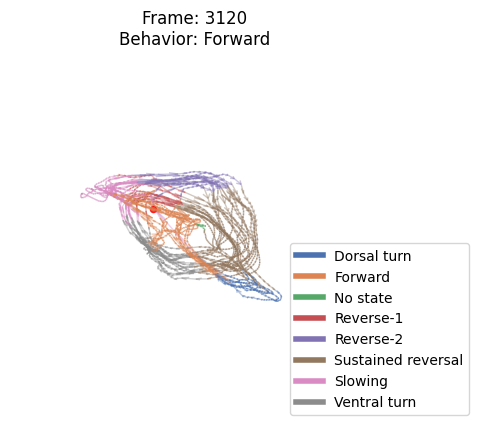

In [10]:
nData = -1
vis = LatentSpaceVisualiser(
    y[:nData], 
    b[:nData], 
    b_names=data.behaviour_names, 
    legend=True
)

ret = vis.make_movie(
    fps=30, 
    filename='../figures/worm_0_movie.gif', 
    show_fig=False,
    #initial_alpha=0.1, # for making background manifold visible
    #fade_time=10, # how many last frames will be displayed
)
